# Mean wind speed fields in Beaufort

In [1]:
## import required packages
import numpy as np
import pandas as pd
import sys
import xarray as xr
import matplotlib.pyplot as plt
import s3fs
import warnings
warnings.filterwarnings("ignore", module='distributed')

In [2]:
from dask.distributed import Client

client = Client("tcp://127.0.0.1:36751")
client

<Client: 'tcp://127.0.0.1:36751' processes=8 threads=32, memory=123.95 GiB>

In [3]:
# initialize s3 filesystem
s3_options = dict(anon=False)

In [4]:
# open geometry file for HH field
HH_grid = xr.open_dataset("~/efs-mount-point/mzahn/sassie/HH/GRID/GRID_GEOMETRY_SASSIE_HH_V1R1_NATIVE_LLC1080.nc")

In [5]:
# function to open zarr store with a provided s3 bucket path
def open_zarr_store(s3_path, s3_options):
    # initalize s3 file system
    s3 = s3fs.S3FileSystem(**s3_options)

    # define location of zarr store and open
    store = s3fs.S3Map(root=s3_path, s3=s3, check=False)
    zarr_store = xr.open_zarr(store)
    
    return zarr_store

Note: ECCO v4r4 is forced with wind stress (see EXFtaux) not vector winds converted to wind stress using bulk formulae. EXFuwind is calculated by converting wind stress to vector wind using bulk formulae.

### Open daily mean ZARR datasets

In [6]:
# open EXFuwind zarr store - Wind speed at 10m in the model +x direction
EXFuwind_da = open_zarr_store('s3://ecco-processed-data/SASSIE/N1/HH/ZARR/EXFuwind_AVG_DAILY.ZARR/', s3_options)

# open EXFvwind zarr store - Wind speed at 10m in the model +y direction
EXFvwind_da = open_zarr_store('s3://ecco-processed-data/SASSIE/N1/HH/ZARR/EXFvwind_AVG_DAILY.ZARR/', s3_options)

In [7]:
# Select beaufort sea region
uwind_beaufort = EXFuwind_da.EXFuwind.rename({'i_g':'i'}).isel(i=slice(450,750),j=slice(110,390))
vwind_beaufort = EXFvwind_da.EXFvwind.rename({'j_g':'j'}).isel(i=slice(450,750),j=slice(110,390))

### Rotate the dataset so Alaska is on the bottom

In [8]:
def rotate_dataarray_90ccw(da):
    """
    Rotate a 3D xarray.DataArray (time, i, j) 90 degrees counterclockwise.
    
    Parameters:
        da (xr.DataArray): Input data array with dims ('time', 'i', 'j').
        
    Returns:
        xr.DataArray: Rotated DataArray with dims ('time', 'i', 'j').
    """
    rotated = np.rot90(da,3,axes=[1,2])
    
    out = xr.DataArray(
        data=rotated,
        dims=('time','i','j'),
        coords={
            'time': da['time'],
            'i': da['i'],
            'j': da['j']
        },
        name=f"{da.name}"
    )
    
    return out

In [9]:
# Rotate the fields so that alaska is on the bottom
uwind_beaufort_rot = rotate_dataarray_90ccw(uwind_beaufort)
vwind_beaufort_rot = rotate_dataarray_90ccw(vwind_beaufort)

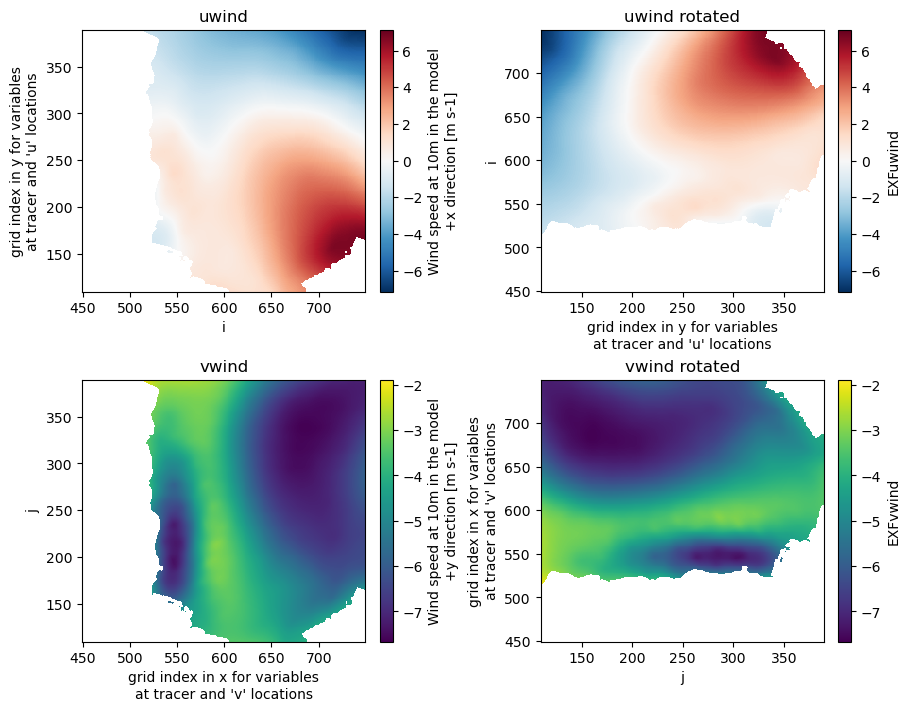

In [10]:
# Double check rotation
fig, ((ax1,ax2),(ax3,ax4)) = plt.subplots(2,2,figsize=[9,7],layout='constrained')
uwind_beaufort.isel(time=200).plot(ax=ax1);
uwind_beaufort_rot.isel(time=200).plot(ax=ax2);
vwind_beaufort.isel(time=200).plot(ax=ax3);
vwind_beaufort_rot.isel(time=200).plot(ax=ax4);
ax1.set_title("uwind")
ax2.set_title("uwind rotated")
ax3.set_title("vwind")
ax4.set_title("vwind rotated");

In [11]:
# Group by month and compute climatological monthly means
uwind_monthly_mean = uwind_beaufort_rot.groupby('time.month').mean('time')
vwind_monthly_mean = vwind_beaufort_rot.groupby('time.month').mean('time')

In [12]:
# Need to multiply j by -1 because we are rotating and the vector sign will change
# Also, with the rotation, the i's (x) become j's (y) and the j's (y) become i's (x)
vwind_monthly_mean_rot = uwind_monthly_mean
uwind_monthly_mean_rot = vwind_monthly_mean*-1

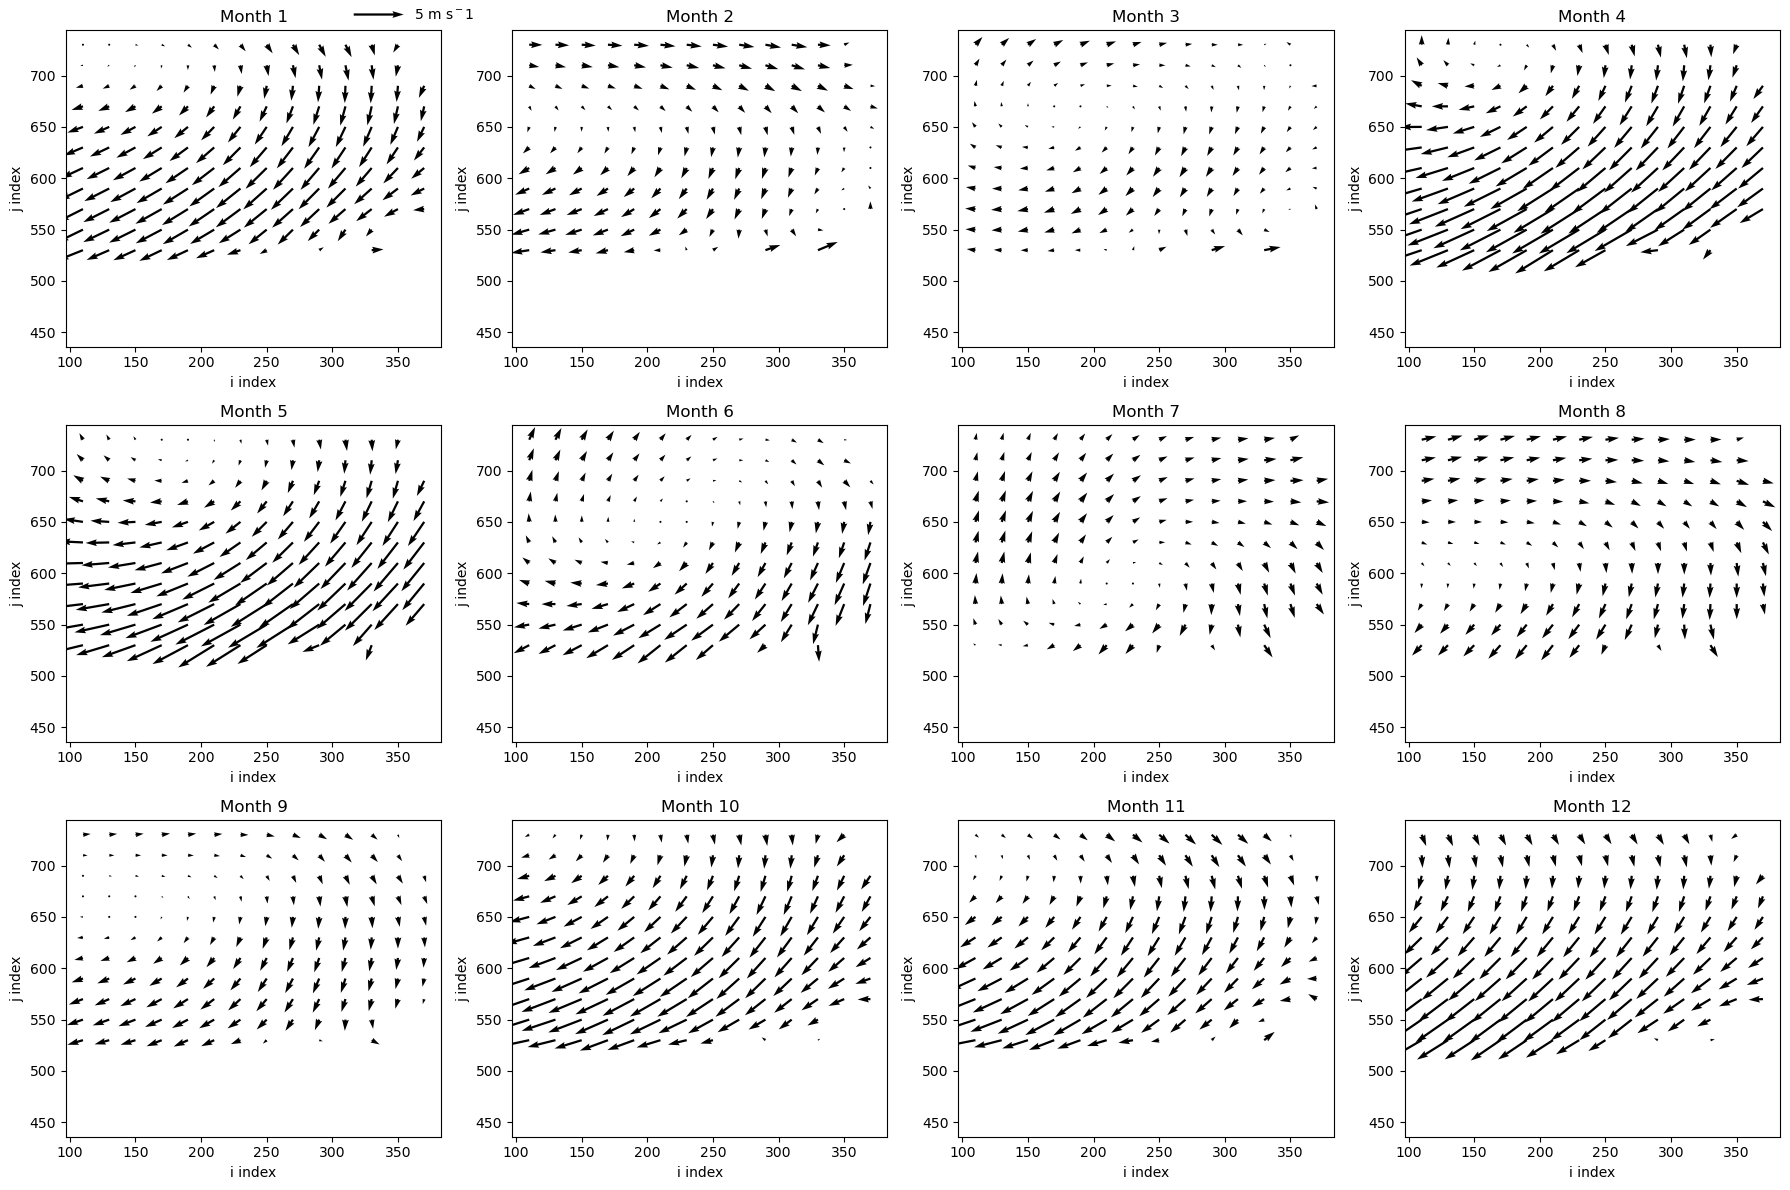

In [13]:
# Subsampling to reduce clutter in quiver plot
step = 20
ii = uwind_monthly_mean_rot['i'][::step]
jj = uwind_monthly_mean_rot['j'][::step]

fig, axs = plt.subplots(3, 4, figsize=(18, 12))
axs = axs.ravel()

# Compute max vector magnitude across all months for consistent scaling
max_magnitude = 0
for i in range(12):
    uwind_sel = uwind_monthly_mean_rot.isel(month=i).sel(i=ii, j=jj)
    vwind_sel = vwind_monthly_mean_rot.isel(month=i).sel(i=ii, j=jj)
    mag = np.sqrt(uwind_sel.values**2 + vwind_sel.values**2)
    max_magnitude = max(max_magnitude, np.nanmax(mag))

# Define a consistent quiver scale
scale = 10

for i in range(12):
    ax = axs[i]
    
    # Select the month (months indexed 0 to 11)
    uwind_sel = uwind_monthly_mean_rot.isel(month=i).sel(i=ii, j=jj)
    vwind_sel = vwind_monthly_mean_rot.isel(month=i).sel(i=ii, j=jj)
    
    # Meshgrid of i and j for quiver input
    j_grid, i_grid = np.meshgrid(jj, ii)
    
    # Use .values to extract data for quiver
    Q = ax.quiver(j_grid, i_grid,
                  uwind_sel.values, vwind_sel.values,
                  scale=scale, angles='uv', scale_units='inches',width=0.006)
    
    ax.set_title(f"Month {i+1}")
    ax.set_xlabel("i index")
    ax.set_ylabel("j index")

    # Add a quiver key to one of the plots (say, first subplot)
    if i == 0:
        ax.quiverkey(Q, 0.9, 1.05, 5, '5 m s${^-1}$',
                     labelpos='E', coordinates='axes')

plt.tight_layout()
plt.show()

In [14]:
# Group by month and compute climatological monthly means
uwind_monthly_mean = uwind_beaufort.groupby('time.month').mean('time')
vwind_monthly_mean = vwind_beaufort.groupby('time.month').mean('time')

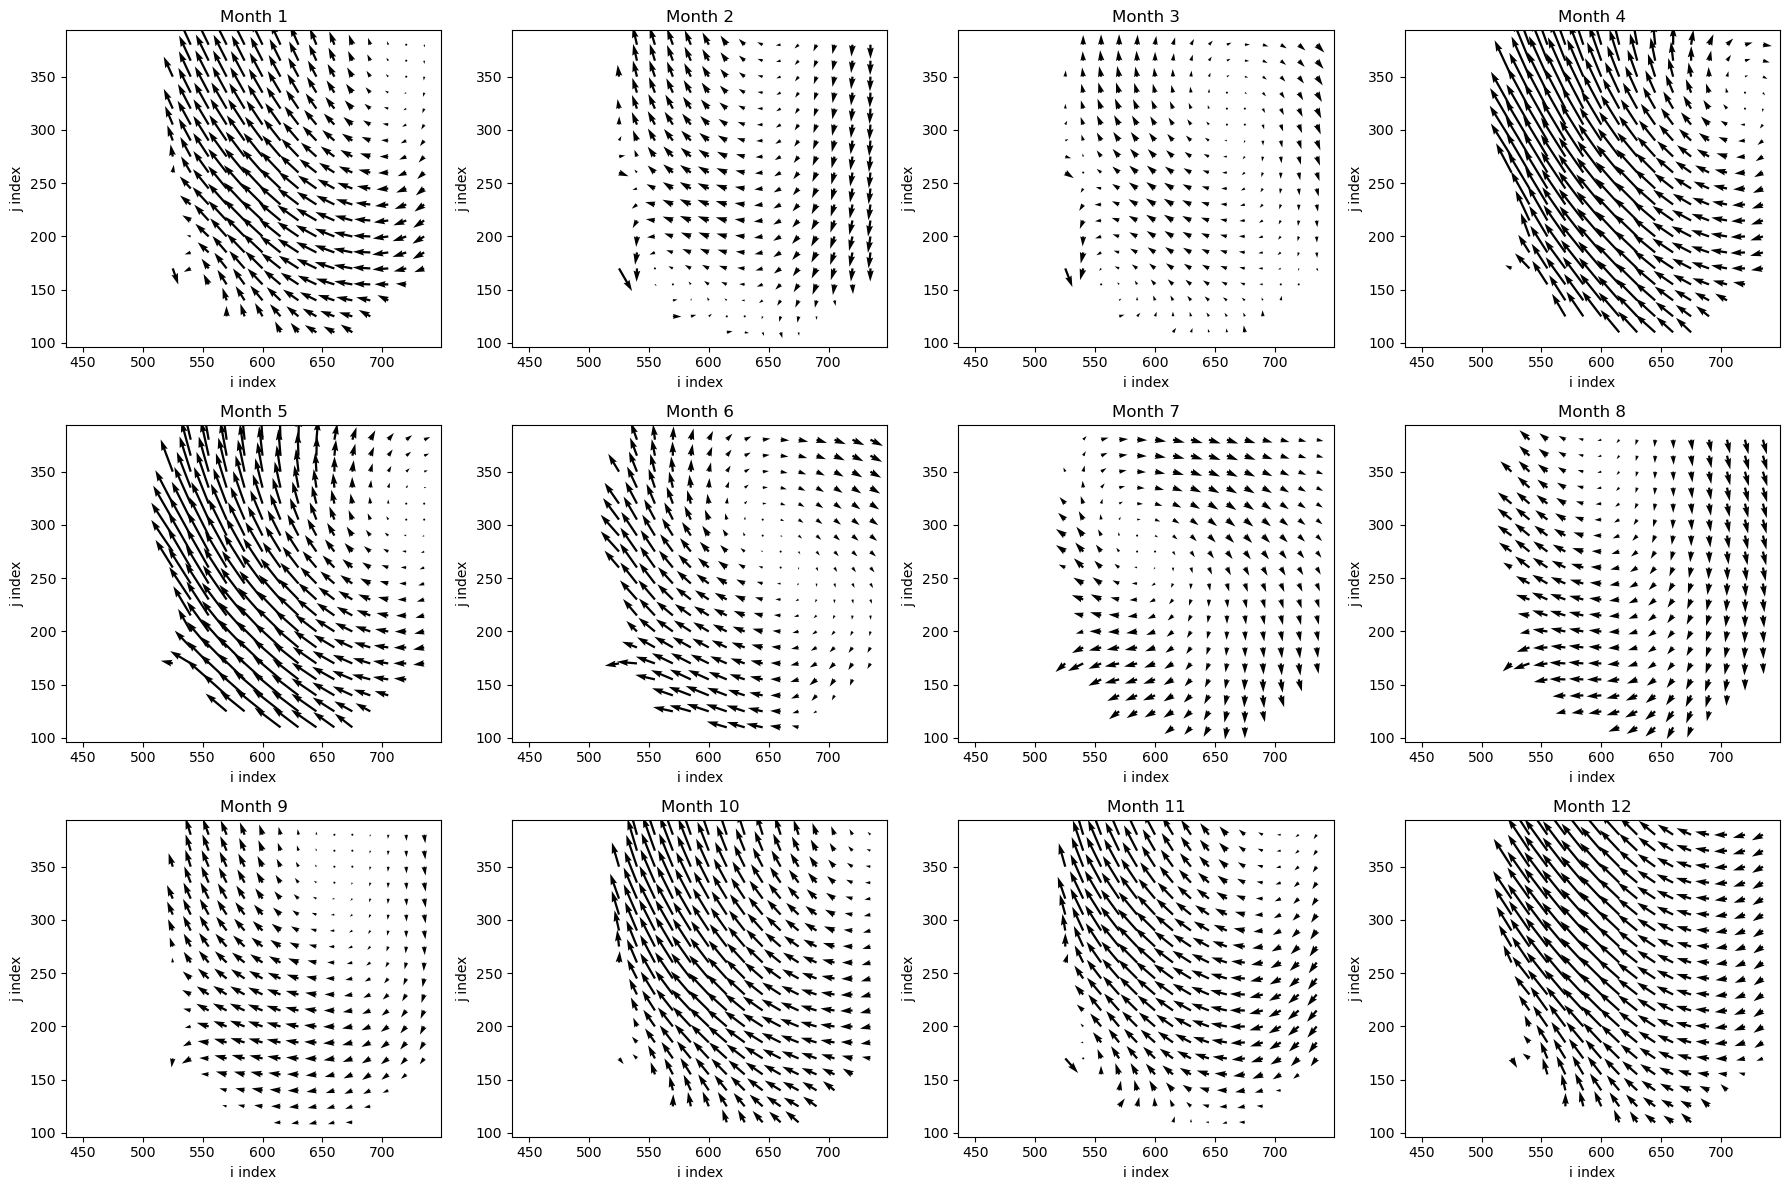

In [15]:
# Subsampling to reduce clutter in quiver plot
step = 15
ii = uwind_monthly_mean['i'][::step]
jj = uwind_monthly_mean['j'][::step]

fig, axs = plt.subplots(3, 4, figsize=(18, 12))
axs = axs.ravel()

# Define a consistent quiver scale
scale = 10

for i in range(12):
    ax = axs[i]
    
    # Select the month (months indexed 0 to 11)
    uwind_sel = uwind_monthly_mean.isel(month=i).sel(i=ii, j=jj)
    vwind_sel = vwind_monthly_mean.isel(month=i).sel(i=ii, j=jj)
    
    # Meshgrid of i and j for quiver input
    i_grid, j_grid = np.meshgrid(ii, jj)
    
    # Use .values to extract data for quiver
    ax.quiver(i_grid, j_grid, uwind_sel.values, vwind_sel.values,scale=scale, angles='uv', scale_units='inches',width=0.006)
    
    ax.set_title(f"Month {i+1}")
    ax.set_xlabel("i index")
    ax.set_ylabel("j index")

plt.tight_layout()
plt.show()

### Plot every month with SSS below and a contour for SI=15%

In [16]:
# open SIarea zarr store - [fraction of sea ice, 0 to 1]
ice_da = open_zarr_store('s3://ecco-processed-data/SASSIE/N1/HH/ZARR/SIarea_AVG_DAILY.ZARR/', s3_options).SIarea*100

# open SALT zarr store - [psu]
salt_da = open_zarr_store('s3://ecco-processed-data/SASSIE/N1/HH/ZARR/SALT_AVG_DAILY.ZARR/', s3_options).SALT

In [17]:
# pull out SSS and SIC for beaufort region
sss_beaufort = salt_da.isel(k=0,i=slice(450,750),j=slice(110,390)).sel(time=slice('2014','2020'))
sic_beaufort = ice_da.isel(i=slice(450,750),j=slice(110,390)).sel(time=slice('2014','2020'))

In [18]:
# Rotate the fields so that alaska is on the bottom
sss_beaufort_rot = rotate_dataarray_90ccw(sss_beaufort)
sic_beaufort_rot = rotate_dataarray_90ccw(sic_beaufort)

In [19]:
# Group by month and compute climatological monthly means
sss_monthly_mean_rot = sss_beaufort_rot.groupby('time.month').mean('time')
sic_monthly_mean_rot = sic_beaufort_rot.groupby('time.month').mean('time')

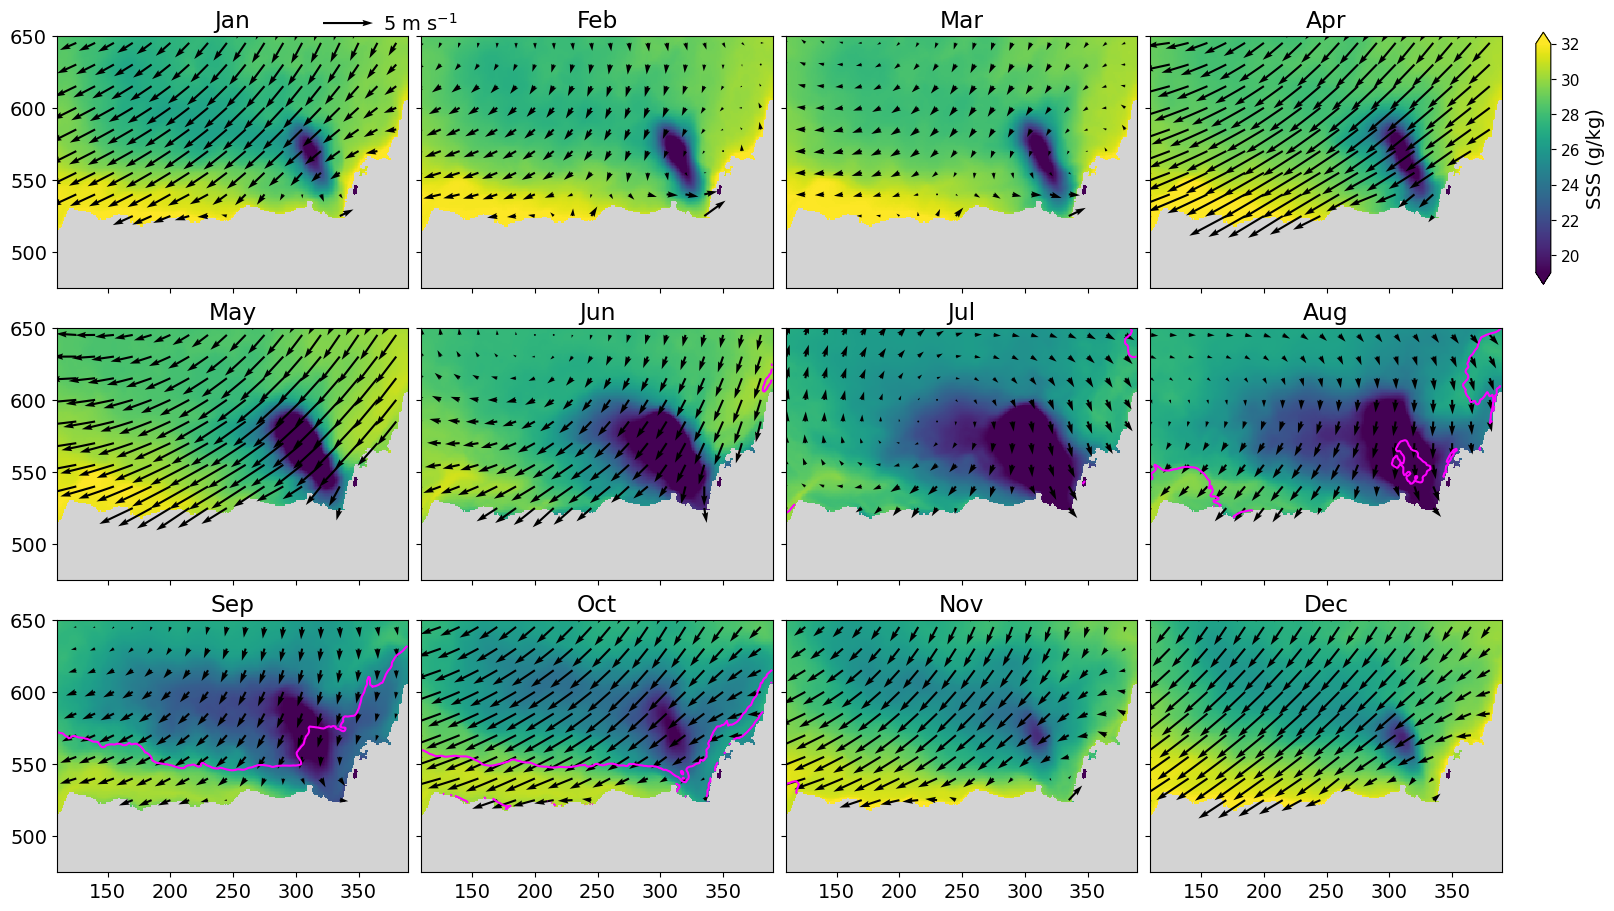

In [20]:
# Subsampling to reduce clutter in quiver plot
plt.rcParams["font.size"] = 14

step = 15
ii = uwind_monthly_mean_rot['i'][::step]
jj = uwind_monthly_mean_rot['j'][::step]

fig, axs = plt.subplots(3, 4, figsize=(15, 9), sharex=True, sharey=True, layout='constrained')
axs = axs.ravel()

# Compute max vector magnitude across all months for consistent scaling
max_magnitude = 0
for i in range(12):
    uwind_sel = uwind_monthly_mean_rot.isel(month=i).sel(i=ii, j=jj)
    vwind_sel = vwind_monthly_mean_rot.isel(month=i).sel(i=ii, j=jj)
    mag = np.sqrt(uwind_sel.values**2 + vwind_sel.values**2)
    max_magnitude = max(max_magnitude, np.nanmax(mag))

# Define a consistent quiver scale
scale = 10

for i in range(12):
    ax = axs[i]

    # Make background gray
    ax.set_facecolor('lightgray')
    
    # Plot SSS for each month
    cbar_plot = sss_monthly_mean_rot.isel(month=i).plot(ax=ax,vmin=19,vmax=32,cmap='viridis',add_colorbar=False,extend='both')
    # sic_monthly_mean_rot.isel(month=i).plot(ax=ax,vmin=0,vmax=100,cmap='Blues_r',add_colorbar=False)
    
    # Plot SIC contour at 15% for each month
    sic_monthly_mean_rot.isel(month=i).plot.contour(ax=ax,levels=[15],linewidths=1.5,colors='magenta')
    
    # Select the month (months indexed 0 to 11)
    uwind_sel = uwind_monthly_mean_rot.isel(month=i).sel(i=ii, j=jj)
    vwind_sel = vwind_monthly_mean_rot.isel(month=i).sel(i=ii, j=jj)
    
    # Meshgrid of i and j for quiver input
    j_grid, i_grid = np.meshgrid(jj, ii)
    
    # Use .values to extract data for quiver
    Q = ax.quiver(j_grid, i_grid,
                  uwind_sel.values, vwind_sel.values,
                  scale=scale, angles='uv', scale_units='inches',width=0.006)
    
    # ax.set_title(f"Month {i+1}", fontsize=16)
    ax.set_title(f"{['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'][i]}")
    ax.set_xlabel("")
    ax.set_ylabel("")
    
    ax.set_ylim(475,650)
    
    # Add a quiver key to one of the plots (say, first subplot)
    if i == 0:
        ax.quiverkey(Q, 0.9, 1.05, 5, '5 m s$^{-1}$',
                     labelpos='E', coordinates='axes')

# Add a single colorbar for SSS
cbar_ax = fig.add_axes([1.02, 0.69, 0.01, 0.28])  # left, bottom, width, height
cbar = fig.colorbar(cbar_plot, cax=cbar_ax, orientation='vertical',extend='both')
cbar.set_label("SSS (g/kg)")
cbar.ax.tick_params(labelsize=11)

plt.show()

### Plot each year August-December

In [23]:
def plot_aug_to_dec(sss_beaufort_rot, sic_beaufort_rot,
                    uwind_beaufort_rot, vwind_beaufort_rot,
                    year=2014, step=15, scale=10):
    """
    Plots August to December monthly means for a specified year (2014–2020)
    from daily data arrays.

    Parameters:
    - sss_beaufort_rot, sic_beaufort_rot, uwind_beaufort_rot, vwind_beaufort_rot: xarray DataArrays with 'time', 'i', 'j' dims
    - year: int (2014 to 2020)
    - step: int, subsampling step for quiver arrows
    - scale: float, quiver scale for quiver plot
    """

    plt.rcParams["font.size"] = 14

    # Subsample grid
    ii = uwind_beaufort_rot['i'][::step]
    jj = uwind_beaufort_rot['j'][::step]

    # Filter data for the selected year
    sss_year = sss_beaufort_rot.sel(time=str(year))
    sic_year = sic_beaufort_rot.sel(time=str(year))
    uwind_year = uwind_beaufort_rot.sel(time=str(year))
    vwind_year = vwind_beaufort_rot.sel(time=str(year))

    # Compute monthly means
    sss_monthly = sss_year.groupby('time.month').mean('time')
    sic_monthly = sic_year.groupby('time.month').mean('time')
    uwind_monthly_tmp = uwind_year.groupby('time.month').mean('time')
    vwind_monthly_tmp = vwind_year.groupby('time.month').mean('time')

    # Need to multiply j by -1 because we are rotating and the vector sign will change
    # Also, with the rotation, the i's (x) become j's (y) and the j's (y) become i's (x)
    vwind_monthly = uwind_monthly_tmp
    uwind_monthly = vwind_monthly_tmp*-1

    # Set up subplots for August–December (months 8–12)
    fig, axs = plt.subplots(1, 5, figsize=(20, 3.5), sharex=True, sharey=True, layout='constrained')

    # Consistent quiver scale based on max magnitude
    max_magnitude = 0
    for m in range(8, 13):
        uwind_sel = uwind_monthly.sel(month=m).sel(i=ii, j=jj)
        vwind_sel = vwind_monthly.sel(month=m).sel(i=ii, j=jj)
        mag = np.sqrt(uwind_sel**2 + vwind_sel**2)
        max_magnitude = max(max_magnitude, np.nanmax(mag))

    for plot_i, month_i in enumerate(range(8, 13)):
        ax = axs[plot_i]
        ax.set_facecolor('lightgray')

        # Plot SSS
        cbar_plot = sss_monthly.sel(month=month_i).plot(ax=ax, vmin=19, vmax=32, cmap='viridis', add_colorbar=False)

        # Plot SIC 15% contour
        sic_monthly.sel(month=month_i).plot.contour(ax=ax, levels=[15], linewidths=1.5, colors='magenta')

        # Quiver arrows
        uwind_sel = uwind_monthly.sel(month=month_i).sel(i=ii, j=jj)
        vwind_sel = vwind_monthly.sel(month=month_i).sel(i=ii, j=jj)
        j_grid, i_grid = np.meshgrid(jj, ii)

        Q = ax.quiver(j_grid, i_grid,
                      uwind_sel.values, vwind_sel.values,
                      scale=scale, angles='uv', scale_units='inches', width=0.006)

        if plot_i == 0:
            ax.quiverkey(Q, 0.9, 1.05, 5, '5 m s$^{-1}$',
                         labelpos='E', coordinates='axes')

        ax.set_title(f"{['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'][month_i-1]}", fontsize=20)
        ax.set_xlabel("")
        ax.set_ylabel("")
        ax.set_ylim(475,650)
        
    fig.text(0.01,1.01,year, fontsize=22)

    # Add a single colorbar for SSS
    cbar_ax = fig.add_axes([1.01, 0.09, 0.01, 0.8])  # left, bottom, width, height
    cbar = fig.colorbar(cbar_plot, cax=cbar_ax, orientation='vertical',extend='both')
    cbar.set_label("SSS (g/kg)")
    cbar.ax.tick_params(labelsize=11)
    
    plt.show()

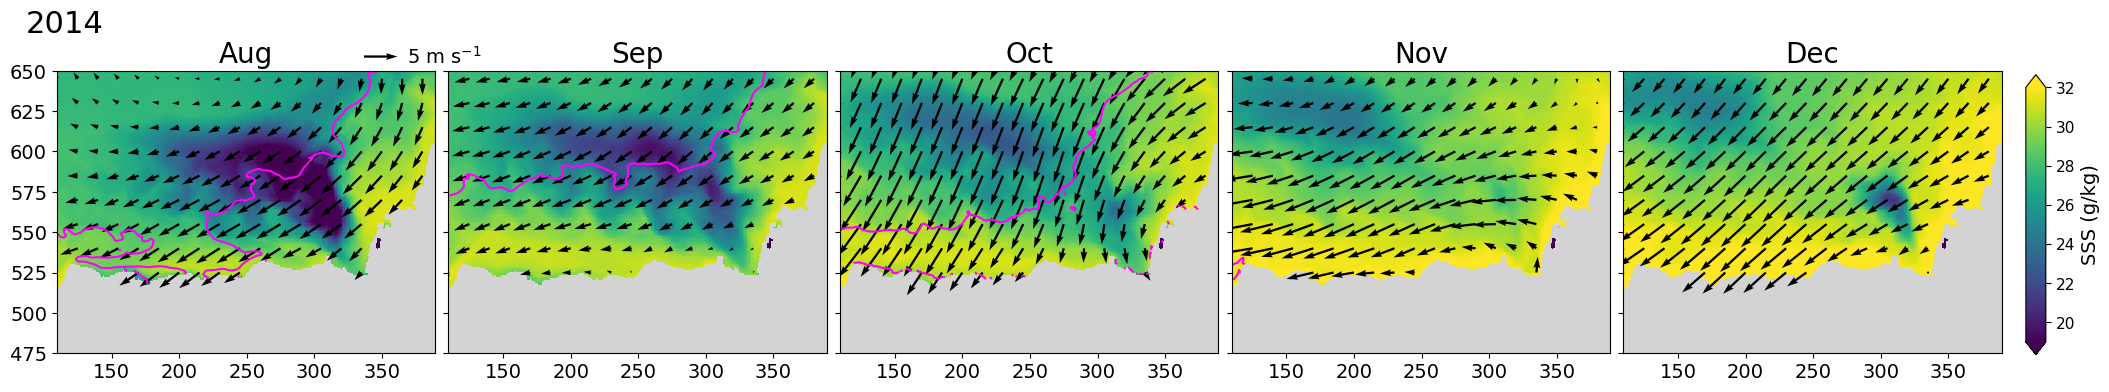

In [24]:
# 2014
plot_aug_to_dec(sss_beaufort_rot, sic_beaufort_rot,uwind_beaufort_rot, vwind_beaufort_rot,year=2014,scale=15)

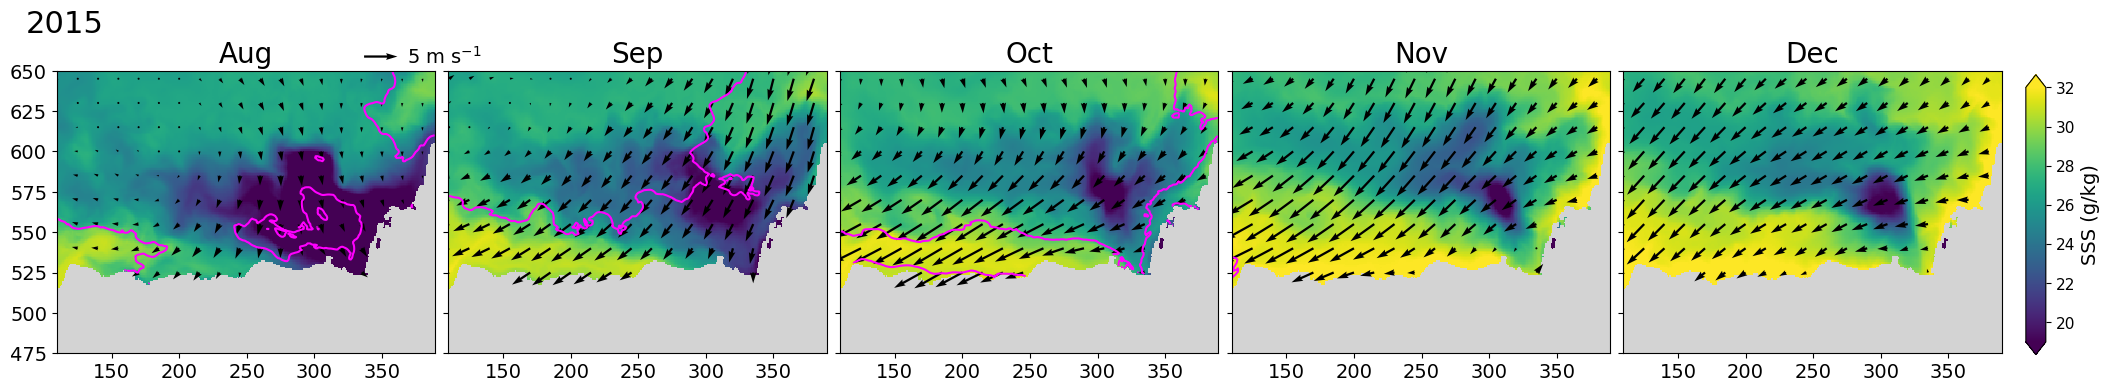

In [25]:
# 2015
plot_aug_to_dec(sss_beaufort_rot, sic_beaufort_rot,uwind_beaufort_rot, vwind_beaufort_rot,year=2015,scale=15)

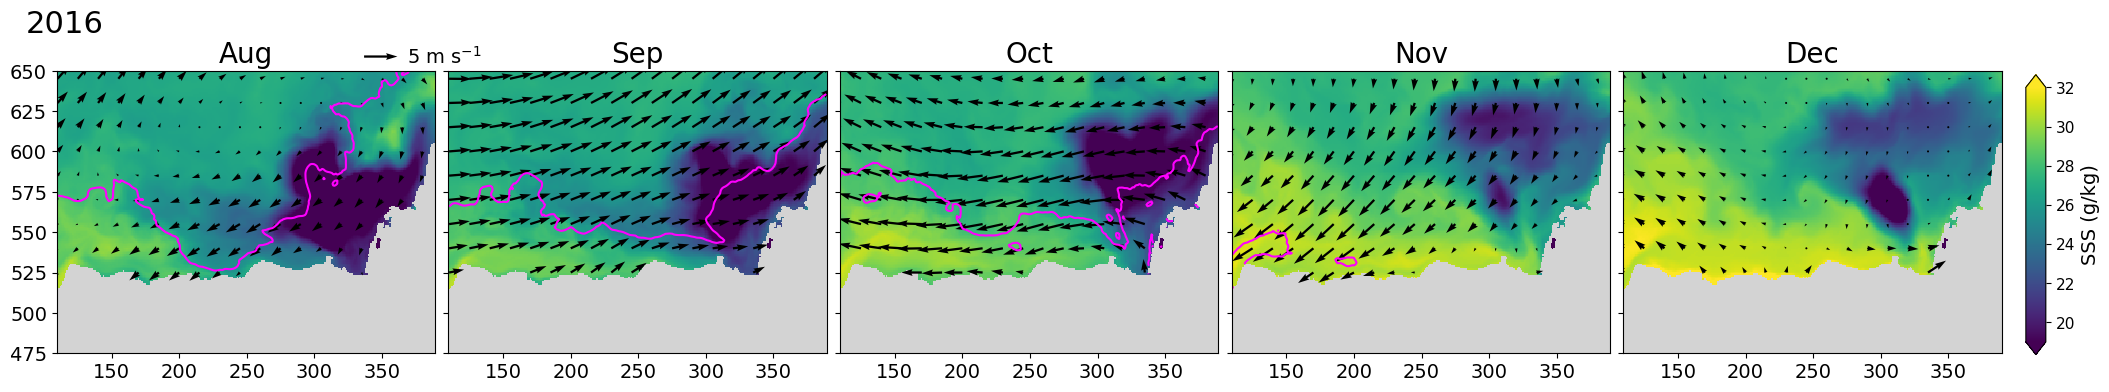

In [26]:
# 2016
plot_aug_to_dec(sss_beaufort_rot, sic_beaufort_rot,uwind_beaufort_rot, vwind_beaufort_rot,year=2016,scale=15)

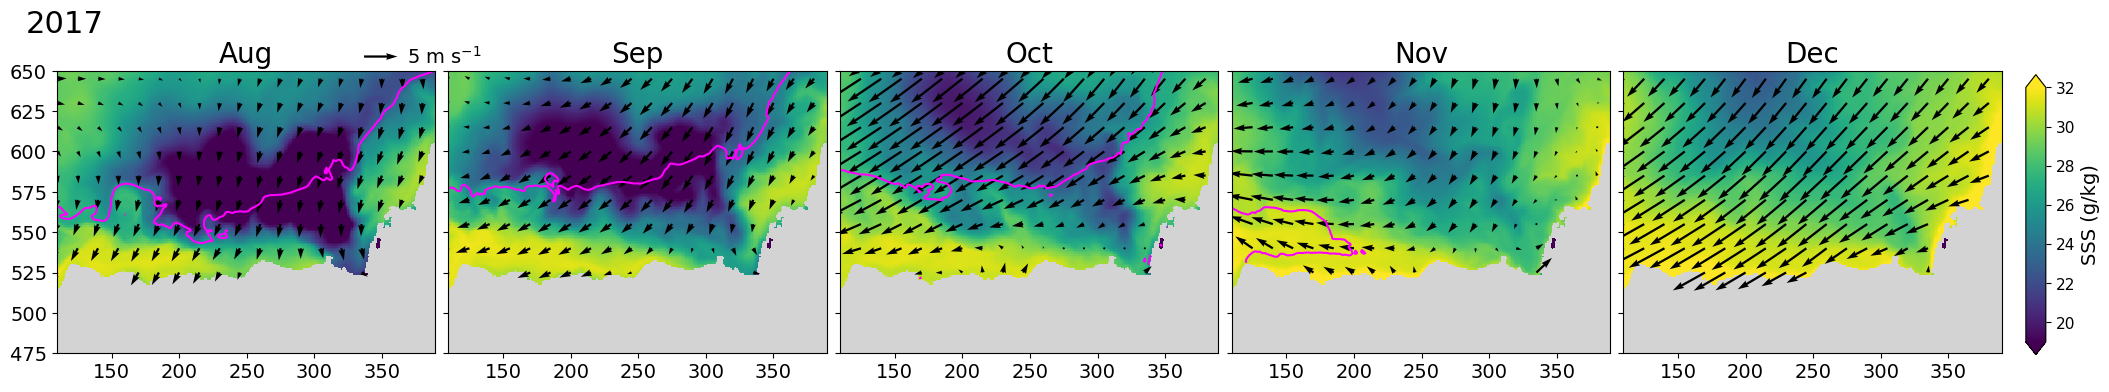

In [27]:
# 2017
plot_aug_to_dec(sss_beaufort_rot, sic_beaufort_rot,uwind_beaufort_rot, vwind_beaufort_rot,year=2017,scale=15)

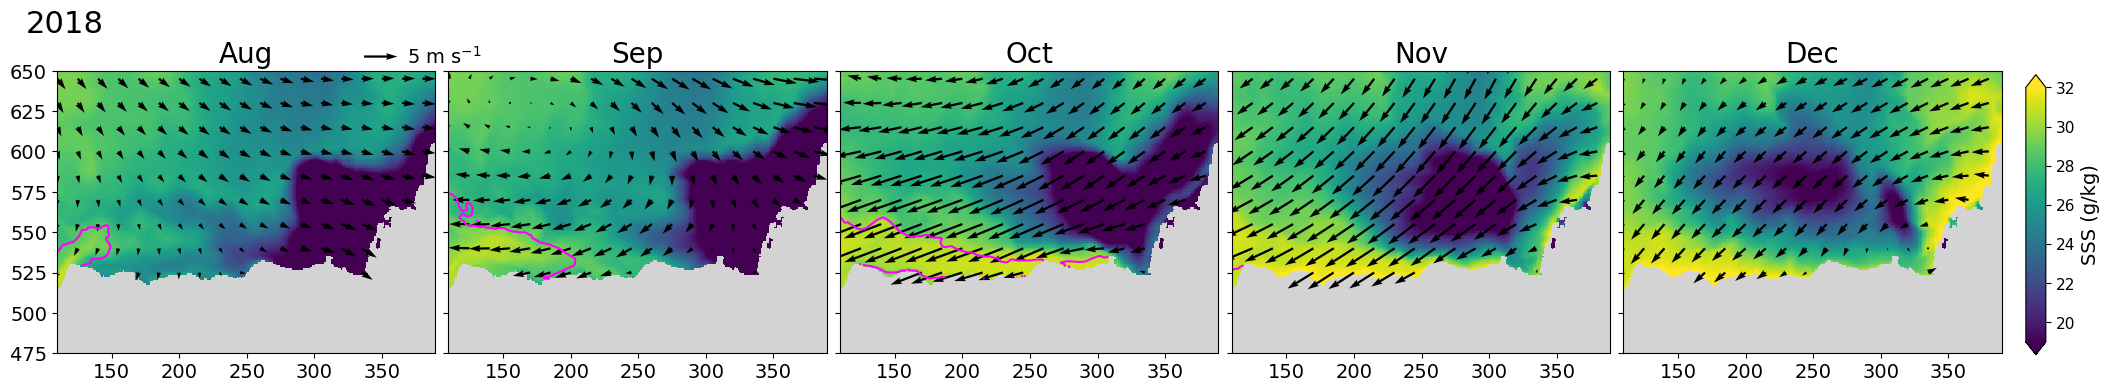

In [28]:
# 2018
plot_aug_to_dec(sss_beaufort_rot, sic_beaufort_rot,uwind_beaufort_rot, vwind_beaufort_rot,year=2018,scale=15)

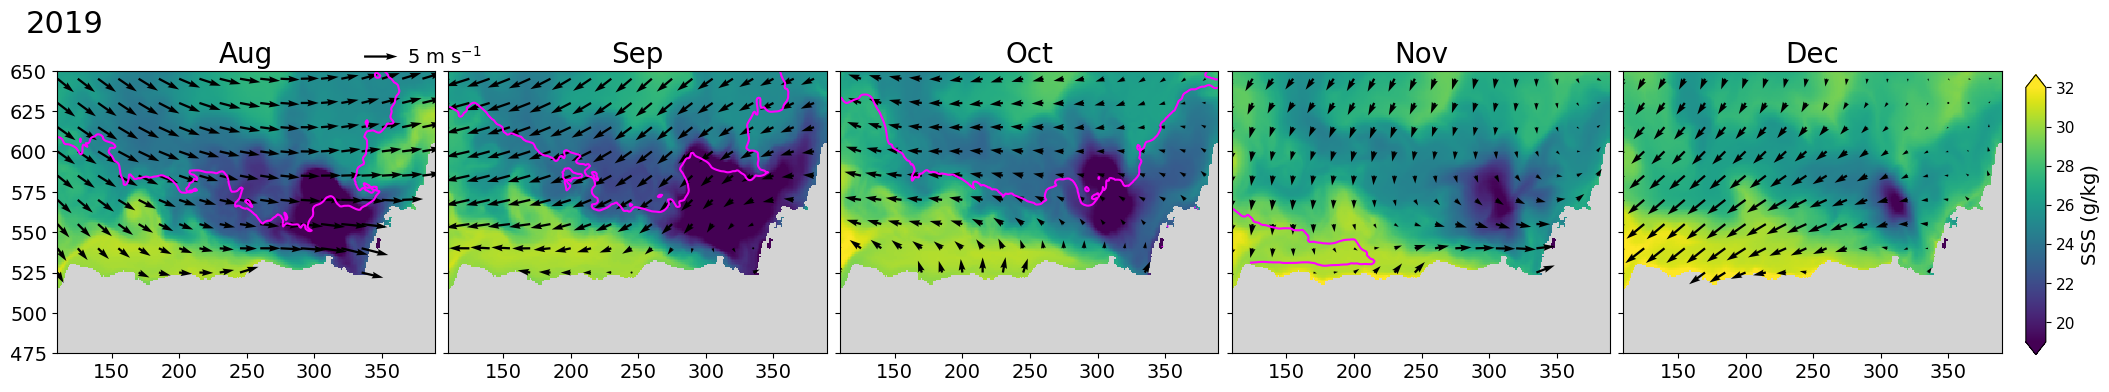

In [29]:
# 2019
plot_aug_to_dec(sss_beaufort_rot, sic_beaufort_rot,uwind_beaufort_rot, vwind_beaufort_rot,year=2019,scale=15)

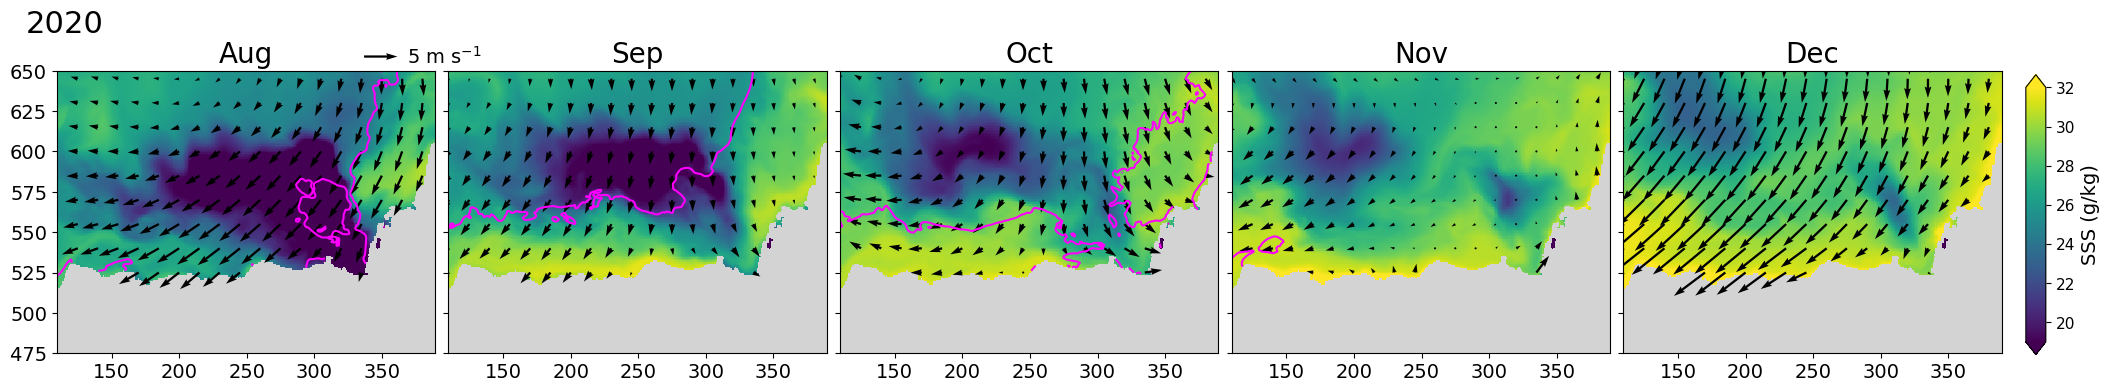

In [30]:
# 2020
plot_aug_to_dec(sss_beaufort_rot, sic_beaufort_rot,uwind_beaufort_rot, vwind_beaufort_rot,year=2020,scale=15)